# 💼 Salary Prediction using Simple Linear Regression

## Project Overview
This project demonstrates an end-to-end machine learning workflow to predict employee salary based on years of experience.  
The goal is to apply industry-standard practices including data cleaning, exploratory data analysis (EDA), model training, prediction, and evaluation using Python and Scikit-learn.


## 1. Import Required Libraries
We begin by importing essential Python libraries for data manipulation, visualization, and machine learning.


In [54]:
#import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset
   The dataset contains employee salary information along with their years of professional experience.


In [55]:
df = pd.read_csv("/content/data.csv")

In [8]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [9]:
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


## 3. Data Understanding & Inspection
In this step, we inspect the dataset structure, data types, and check for missing values.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [19]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## 4. Data Cleaning
We check for missing values and inconsistencies.  
Since the dataset is clean and contains no missing values, no imputation is required.

In [12]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


✔ Dataset is clean with no missing values.

## 5. Exploratory Data Analysis (EDA)
EDA helps us understand relationships between variables, detect outliers, and verify model assumptions.

### 5.1 Pairplot
Pairplot is used to visually inspect the relationship between YearsExperience and Salary and verify linearity.

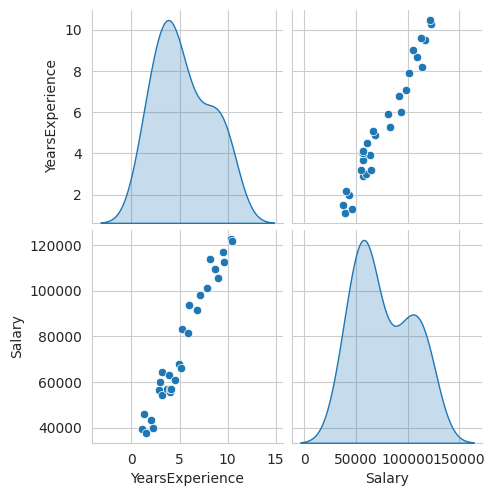

In [23]:
sns.pairplot(df, diag_kind="kde")

## Observation (Markdown):
- A strong positive linear relationship exists between YearsExperience and Salary.
- This confirms that Linear Regression is an appropriate model.


## 5.2 Boxplot – Outlier Detection

### 5.2 Outlier Detection using Boxplot
Boxplots help identify potential outliers that may affect model performance.


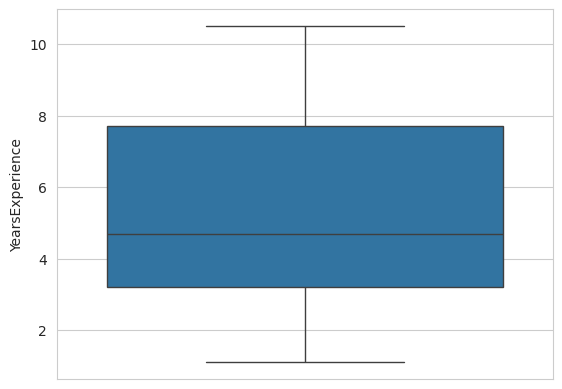

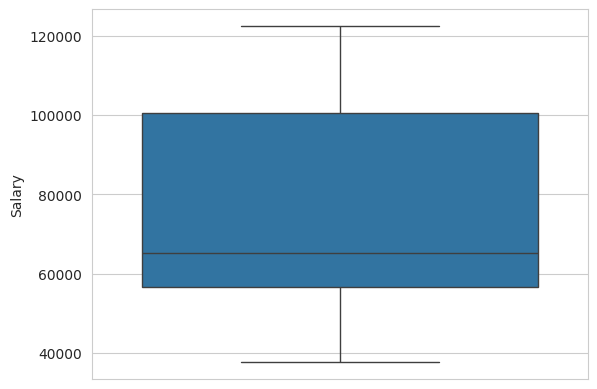

In [26]:
sns.boxplot(y=df['YearsExperience'])
plt.show()

sns.boxplot(y=df['Salary'])
plt.show()

## Observation:

- No significant outliers detected.
- Dataset is suitable for regression modeling.


## 6. Feature Selection & Preprocessing

## 6. Feature Selection & Preprocessing
We select YearsExperience as the independent variable and Salary as the target variable.


In [30]:
x = df[['YearsExperience']]   # 2D → required by sklearn
y = df['Salary']              # 1D target

In [31]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [32]:
y

,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0
5,56642.0
6,60150.0
7,54445.0
8,64445.0
9,57189.0


## 7. Train-Test Split
The dataset is split into training and testing sets to evaluate model generalization.

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Model Creation – Simple Linear Regression

## 8. Model Creation
We train a Simple Linear Regression model using Scikit-learn.

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

## Model Equation
Salary = m × YearsExperience + c

In [56]:
y_pred = model.predict(x_test)

## 9. Prediction
The trained model is used to predict salaries on the test dataset.


In [47]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

## 10. Model Evaluation
We evaluate the model using standard regression metrics.


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 6286.453830757749
MSE: 49830096.85590839
RMSE: 7059.04362190151
R2 Score: 0.9024461774180497


### Evaluation Summary
- MAE indicates the average prediction error in salary units.
- RMSE provides error magnitude while penalizing large errors.
- R² score shows that ~90% of salary variance is explained by experience.

✔ The model demonstrates strong predictive performance for a single-feature regression task.


## 11. Regression Line Visualization


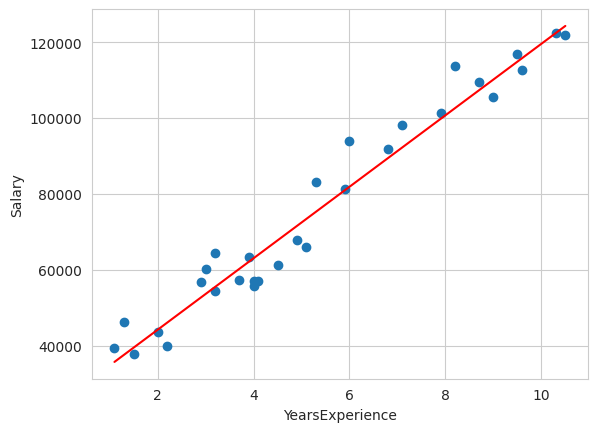

In [50]:
import matplotlib.pyplot as plt

plt.scatter(x, y)
plt.plot(x, model.predict(x), color='red')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()


## 12. Residual Analysis
Residual plots help verify linear regression assumptions.


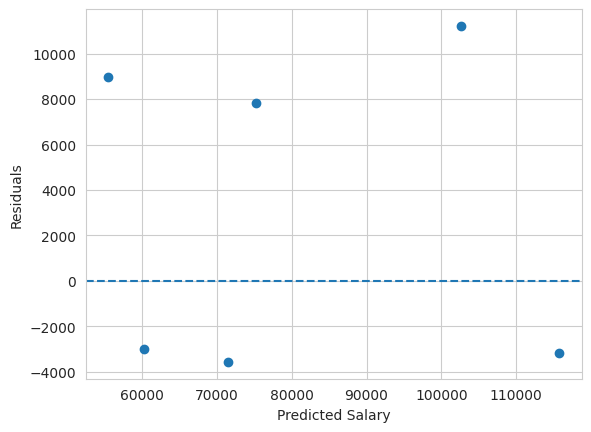

In [51]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.show()


## 13. Conclusion
This project successfully demonstrates an end-to-end machine learning pipeline:
- Clean data
- Strong linear relationship
- Well-performing regression model
- Clear evaluation and interpretation

The model can be further improved by adding more features such as education level, job role, and location.
